In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [74]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import Binarizer

In [26]:
df = pd.read_csv('Housing2.csv')

In [27]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [28]:
df = df[['sqft_living','sqft_lot','sqft_above','sqft_basement','price']]

In [29]:
df = df.iloc[:1000,:]

In [30]:
df.describe()

,sqft_living,sqft_lot,sqft_above,sqft_basement,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2051.196000,14702.085000,1750.333000,300.863000,5.204242e+05
std,887.929222,28961.030775,790.077476,450.898196,3.394803e+05
min,380.000000,649.000000,380.000000,0.000000,8.000000e+04
25%,1407.500000,5428.500000,1190.000000,0.000000,3.094500e+05
50%,1900.000000,8045.000000,1540.000000,0.000000,4.350000e+05
75%,2472.500000,11489.250000,2132.500000,580.000000,6.336938e+05
max,6070.000000,315374.000000,6070.000000,2060.000000,3.075000e+06


In [35]:
x = df.drop(columns=['price'])
y = df.iloc[:,-1]

In [36]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['price']),df[['price']],test_size=0.2,random_state=42)

In [45]:
pt = PowerTransformer()

X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

rg = DecisionTreeRegressor()

rg.fit(X_train_transformed, y_train)
y_pred = rg.predict(X_test_transformed)

r2_score(y_test, y_pred)

0.14324032832529054

In [52]:
rg = DecisionTreeRegressor()

rg.fit(X_train, y_train)
y_pred = rg.predict(X_test)

r2_score(y_test, y_pred)

0.038834062508186995

In [62]:
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2_score(y_test, y_pred)

0.43783207113472744

In [64]:
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2_score(y_test, y_pred)

0.43783207113472744

In [65]:
X_train

,sqft_living,sqft_lot,sqft_above,sqft_basement,sqft_liv_bin
29,2570,7173,2570,0,2.0
535,1610,6655,1610,0,0.0
695,1410,5760,1410,0,0.0
557,1400,7242,1400,0,0.0
836,1350,4003,1350,0,0.0
...,...,...,...,...,...
106,1670,4005,1170,500,1.0
270,5310,57346,5310,0,4.0
860,380,15000,380,0,0.0
435,1710,9627,1440,270,1.0


In [53]:
kbin_sqft_living = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='kmeans')

In [55]:
X_train['sqft_liv_bin'] = kbin_sqft_living.fit_transform(X_train[['sqft_living']])

In [57]:
X_test['sqft_liv_bin'] = kbin_sqft_living.transform(X_test[['sqft_living']])

In [59]:
kbin_sqft_living.n_bins_

array([5])

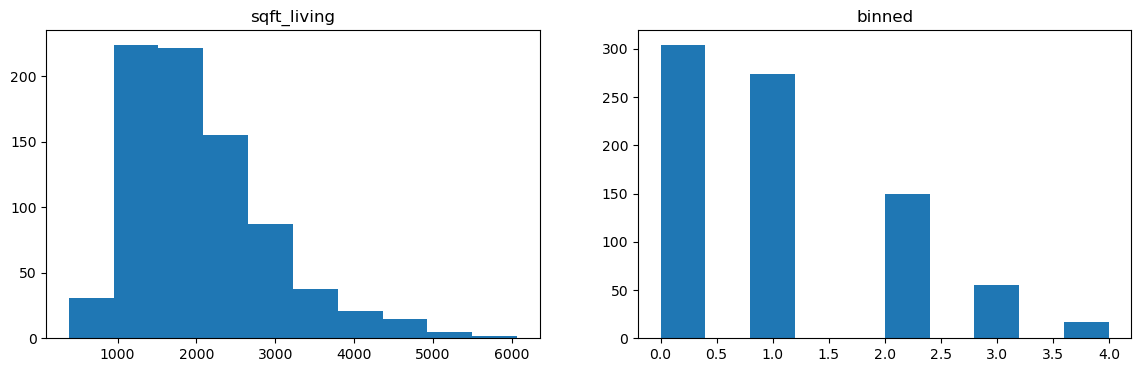

In [63]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.hist(X_train['sqft_living'])
plt.title('sqft_living')

plt.subplot(1,2,2)
plt.hist(X_train['sqft_liv_bin'])
plt.title('binned')

plt.show()

In [71]:
def discretize(bins, strategy):
    kbin_sqft_living = KBinsDiscretizer(n_bins=bins, encode='ordinal',strategy=strategy, quantile_method='averaged_inverted_cdf')
    X_train['sqft_liv_bin'] = kbin_sqft_living.fit_transform(X_train[['sqft_living']])

    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    plt.hist(X_train['sqft_living'])
    plt.title('sqft_living')
    
    plt.subplot(1,2,2)
    plt.hist(X_train['sqft_liv_bin'])
    plt.title('binned')
    
    plt.show()
    

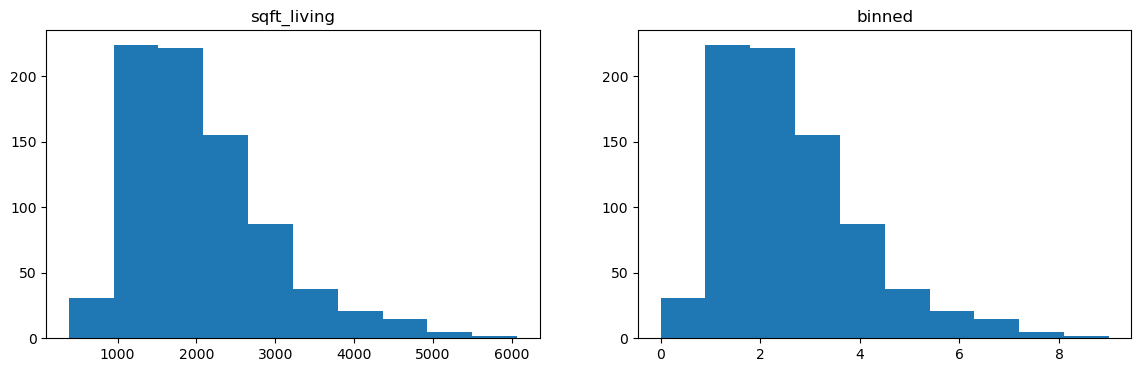

In [73]:
discretize(10, 'uniform')

In [75]:
binarizer = Binarizer(copy=False)

In [79]:
X_train['sqft_basement'] = binarizer.fit_transform(X_train[['sqft_basement']])

In [85]:
X_train['sqft_basement'].value_counts()

sqft_basement
0    476
1    324
Name: count, dtype: int64